In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Tweets.csv")

df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [5]:
df.shape

(14640, 15)

In [6]:
df.columns

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')

In [7]:
df['airline_sentiment'].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

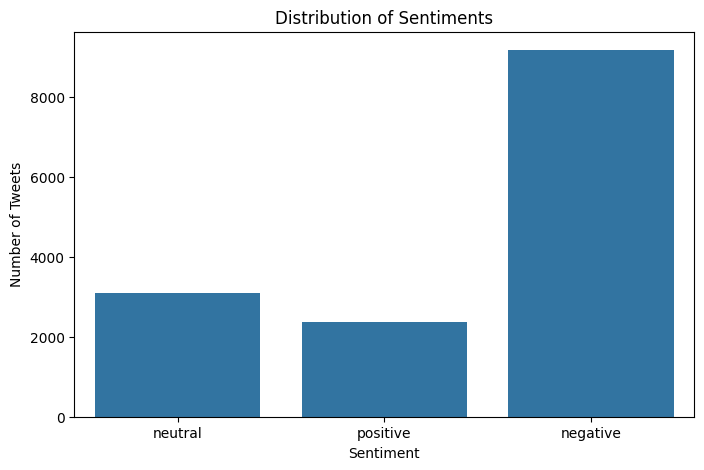

In [8]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='airline_sentiment')

plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()

In [9]:
df[['text', 'airline_sentiment']].head()

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [11]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASIYA\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASIYA\AppData\Roaming\nltk_data...


True

In [12]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

print("Text preprocessing tools are ready!")

Text preprocessing tools are ready!


In [14]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]
    
    return ' '.join(words)

In [15]:
sample_text = df['text'].iloc[0]

print("Original:")
print(sample_text)

print("\nCleaned:")
print(preprocess_text(sample_text))

Original:
@VirginAmerica What @dhepburn said.

Cleaned:
virginamerica dhepburn said


In [16]:
df['cleaned_text'] = df['text'].apply(preprocess_text)

In [17]:
df[['text', 'cleaned_text']].head()

,text,cleaned_text
0,@VirginAmerica What @dhepburn said.,virginamerica dhepburn said
1,@VirginAmerica plus you've added commercials t...,virginamerica plus youve added commercial expe...
2,@VirginAmerica I didn't today... Must mean I n...,virginamerica didnt today must mean need take ...
3,@VirginAmerica it's really aggressive to blast...,virginamerica really aggressive blast obnoxiou...
4,@VirginAmerica and it's a really big bad thing...,virginamerica really big bad thing


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [19]:
tfidf = TfidfVectorizer(max_features=5000)

### TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) converts text into numerical features that can be used by machine learning models. It gives higher importance to words that are frequent in a particular document but less common across the entire dataset.

In [20]:
X = tfidf.fit_transform(df['cleaned_text'])

print("TF-IDF matrix shape:", X.shape)

TF-IDF matrix shape: (14640, 5000)


In [21]:
y = df['airline_sentiment']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (11712, 5000)
Testing data: (2928, 5000)


In [24]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [25]:
y_pred_nb = nb_model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [26]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [27]:
y_pred_lr = lr_model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [29]:
print("Naive Bayes Results")
print("-------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_nb, average='weighted'))
print("F1-score :", f1_score(y_test, y_pred_nb, average='weighted'))

Naive Bayes Results
-------------------
Accuracy : 0.7281420765027322
Precision: 0.7420408570851439
Recall   : 0.7281420765027322
F1-score : 0.6817005126028212


In [30]:
print("Logistic Regression Results")
print("---------------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_lr, average='weighted'))
print("F1-score :", f1_score(y_test, y_pred_lr, average='weighted'))

Logistic Regression Results
---------------------------
Accuracy : 0.7882513661202186
Precision: 0.7803696583529607
Recall   : 0.7882513661202186
F1-score : 0.7767645168496415


In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

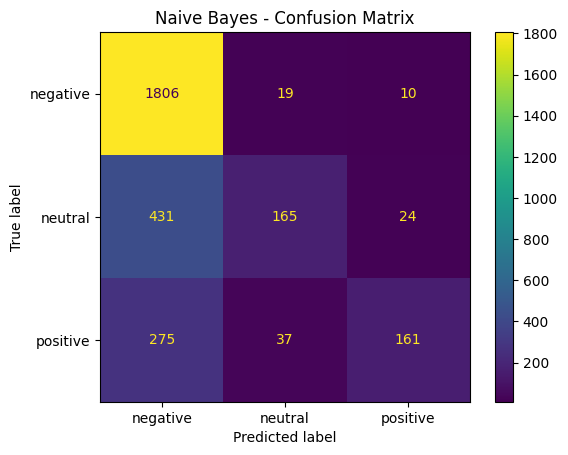

In [32]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

disp_nb = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=['negative', 'neutral', 'positive']
)

disp_nb.plot()
plt.title('Naive Bayes - Confusion Matrix')
plt.show()

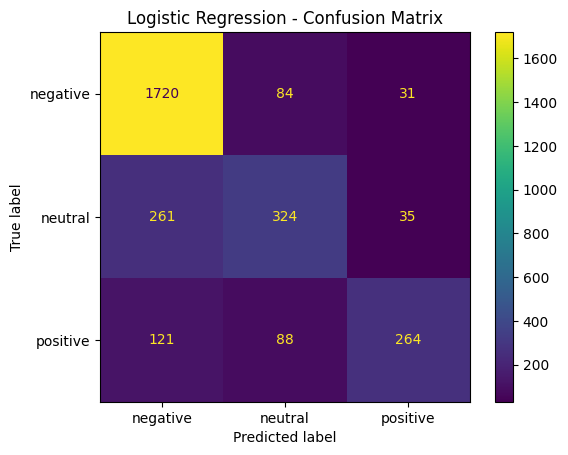

In [33]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=['negative', 'neutral', 'positive']
)

disp_lr.plot()
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

In [35]:
from wordcloud import WordCloud

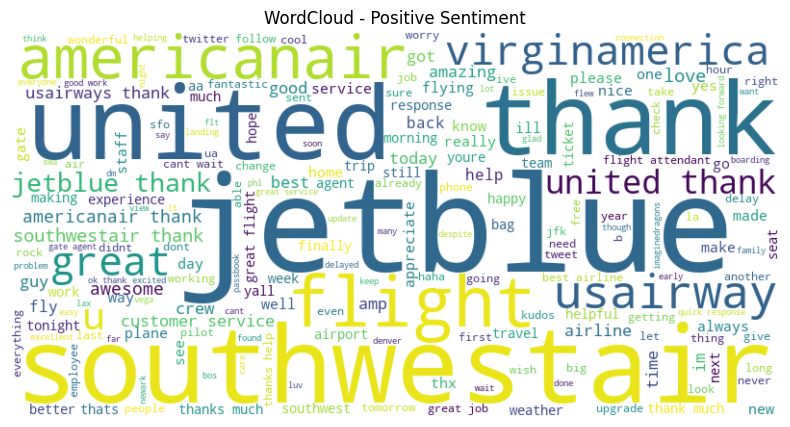

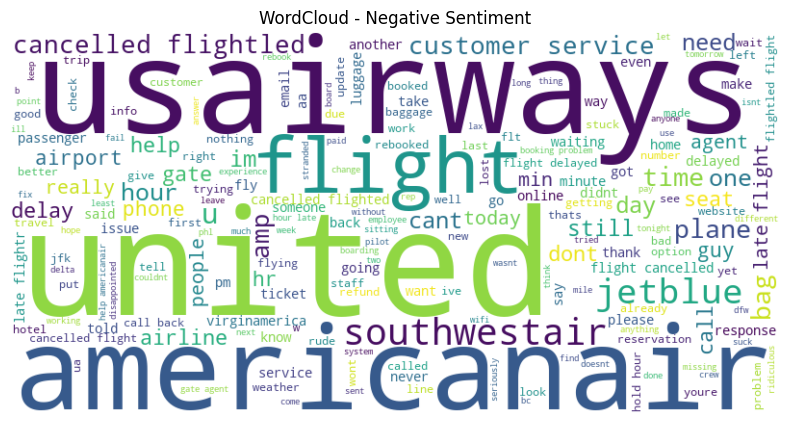

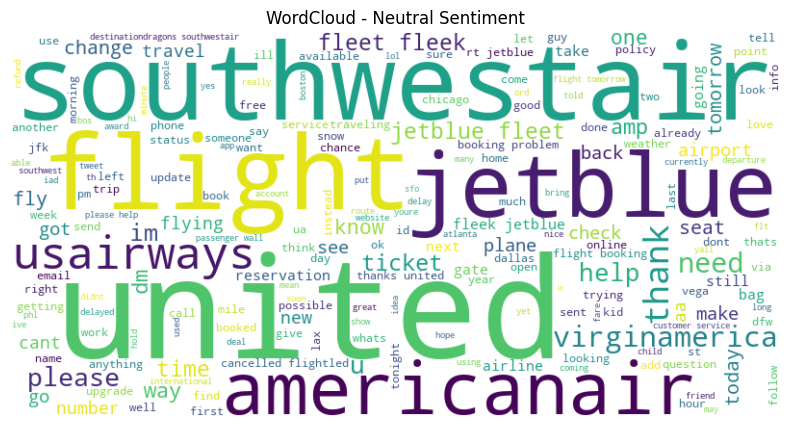

In [36]:
sentiments = ['positive', 'negative', 'neutral']

for sentiment in sentiments:
    text = ' '.join(
        df[df['airline_sentiment'] == sentiment]['cleaned_text']
    )
    
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'WordCloud - {sentiment.capitalize()} Sentiment')
    plt.show()

In [37]:
misclassified = df.loc[
    y_test.index[y_test != y_pred_lr],
    ['text', 'airline_sentiment']
].copy()

misclassified.head(5)

,text,airline_sentiment
2998,@united past,neutral
7719,@JetBlue would you say a delay is more likely?...,positive
4006,@united This link in your tweet goes to someon...,neutral
4686,@SouthwestAir When will the flight resume? I d...,negative
8985,@USAirways Well I did miss it. But gate agents...,positive


In [38]:
error_analysis = pd.DataFrame({
    'Original Text': df.loc[y_test.index, 'text'],
    'Actual Sentiment': y_test,
    'Predicted Sentiment': y_pred_lr
})

misclassified = error_analysis[
    error_analysis['Actual Sentiment'] != error_analysis['Predicted Sentiment']
]

misclassified.head(5)

,Original Text,Actual Sentiment,Predicted Sentiment
2998,@united past,neutral,negative
7719,@JetBlue would you say a delay is more likely?...,positive,negative
4006,@united This link in your tweet goes to someon...,neutral,negative
4686,@SouthwestAir When will the flight resume? I d...,negative,neutral
8985,@USAirways Well I did miss it. But gate agents...,positive,negative


### Error Analysis

The model misclassified some tweets because sentiment can be difficult to determine from short and informal text. Tweets may contain ambiguous words, incomplete sentences, questions, sarcasm, or context that is not fully captured by TF-IDF features. In some cases, positive and negative expressions may appear together, making the sentiment harder to classify correctly.

## Conclusion

In this project, sentiment analysis was performed on Twitter airline-related tweets using TF-IDF feature extraction and two machine learning classifiers: Multinomial Naive Bayes and Logistic Regression.

The results show that Logistic Regression performed better than Naive Bayes, achieving an accuracy of approximately 78.83% and an F1-score of approximately 77.68%. Naive Bayes achieved an accuracy of approximately 72.81% and an F1-score of approximately 68.17%.

The model can be applied to real-world applications such as analyzing customer feedback, monitoring public opinion, and identifying customer satisfaction or complaints on social media platforms.